In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# 0 = all messages are logged (default behavior)
# 1 = INFO messages are not printed
# 2 = INFO and WARNING messages are not printed
# 3 = INFO, WARNING, and ERROR messages are not printed

import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
#from google.colab import drive
#drive.mount('/content/gdrive')

mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

#import warnings
# https://stackoverflow.com/questions/15777951/how-to-suppress-pandas-future-warning
#warnings.simplefilter(action='ignore', category=FutureWarning)
#warnings.simplefilter(action='ignore', category=Warning)

tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

import logging
tf.get_logger().setLevel(logging.ERROR)

# https://stackoverflow.com/questions/65697623/tensorflow-warning-found-untraced-functions-such-as-lstm-cell-6-layer-call-and
import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from keras.models import load_model

In [2]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Thu Sep  7 23:43:04 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.105.17   Driver Version: 525.105.17   CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA A100-SXM...  Off  | 00000000:00:04.0 Off |                    0 |
| N/A   34C    P0    44W / 400W |      0MiB / 40960MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [3]:
# Mounting Drive
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [4]:
%cd /content/drive/My Drive/TX_DATA/BestData

/content/drive/My Drive/TX_DATA/BestData


In [5]:
#Read In Data
dfs = {}
for index in range(0, 6):
  df = pd.read_csv('Station' + str(index + 1) + '-Simulated-cleaned-merged-data.csv', sep=",", parse_dates=["Date"], index_col="Date")
  dfs['Station' + str(index + 1)] = df

# Vectorize wind
for station, df in dfs.items():
  wv = df.pop('Windspeed')
  wd_rad = df.pop('Winddirection')*np.pi / 180
  df['Wx'] = wv*np.cos(wd_rad)
  df['Wy'] = wv*np.sin(wd_rad)
  dfs[station] = df

# Remove periodicity in time data (remove daily and yearly periodicity)
day = 24*60*60
year = (365.2425)*day

for station, df in dfs.items() :
  timestamp_s = (df.index).map(pd.Timestamp.timestamp)
  df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
  df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
  df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
  df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))
  dfs[station] = df

for station, df in dfs.items():
  lat = df.pop('Latitude')
  lon = df.pop('Longitude')
  df["x_cord"] = np.cos(lat) * np.cos(lon)
  df["y_cord"] = np.sin(lat) * np.cos(lon)
  df["z_cord"] = np.sin(lon)
  dfs[station] = df





In [6]:
dfs["Station1"].head()

,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Tair,RH,...,Ppt,Wx,Wy,Day sin,Day cos,Year sin,Year cos,x_cord,y_cord,z_cord
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,-1.090,81.5,...,0.0,0.643762,0.832030,1.232357e-12,1.000000,0.001505,0.999999,-0.180165,0.291386,0.939486
2015-01-01 01:00:00,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,-1.038,81.7,...,0.0,0.657578,0.698049,2.588190e-01,0.965926,0.002222,0.999998,-0.180165,0.291386,0.939486
2015-01-01 02:00:00,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,-0.981,82.0,...,0.0,0.653248,0.837324,5.000000e-01,0.866025,0.002939,0.999996,-0.180165,0.291386,0.939486
2015-01-01 03:00:00,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,-0.814,81.9,...,0.0,0.458032,0.759589,7.071068e-01,0.707107,0.003656,0.999993,-0.180165,0.291386,0.939486
2015-01-01 04:00:00,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,-0.805,90.0,...,0.0,0.793697,0.235857,8.660254e-01,0.500000,0.004372,0.999990,-0.180165,0.291386,0.939486


In [7]:
#Use only overlapping indexes
index_union = pd.Index([])
for station, df in dfs.items():
  index_union = index_union.union(df.index)
index_int = index_union
for station, df in dfs.items():
  index_int = index_int.intersection(df.index)

In [8]:
for key in dfs.keys():
  dfs[key] = dfs[key].loc[index_int]

In [9]:
for key, df in dfs.items():
  print(key, df.shape)

Station1 (55028, 21)
Station2 (55028, 21)
Station3 (55028, 21)
Station4 (55028, 21)
Station5 (55028, 21)
Station6 (55028, 21)


In [10]:
from sklearn.preprocessing import MinMaxScaler


for key, df in dfs.items():
  cur_df = df.copy()
  d_sin = cur_df.pop("Day sin")
  print(type(d_sin), key)
  d_cos = cur_df.pop("Day cos")
  y_sin = cur_df.pop("Year sin")
  y_cos = cur_df.pop("Year cos")
  x = cur_df.pop("x_cord")
  y = cur_df.pop("y_cord")
  z = cur_df.pop("z_cord")
  scaler = MinMaxScaler()
  scaled_df = pd.DataFrame(data = scaler.fit_transform(cur_df), columns = cur_df.columns)
  scaled_df["Day sin"] = d_sin
  scaled_df["Day cos"] = d_cos
  scaled_df["Year sin"] = y_sin
  scaled_df["Year cos"] = y_cos
  scaled_df["x_cord"] = x
  scaled_df["y_cord"] = y
  scaled_df["z_cord"] = z
  df = scaled_df




<class 'pandas.core.series.Series'> Station1
<class 'pandas.core.series.Series'> Station2
<class 'pandas.core.series.Series'> Station3
<class 'pandas.core.series.Series'> Station4
<class 'pandas.core.series.Series'> Station5
<class 'pandas.core.series.Series'> Station6


In [11]:
dfs["Station1"]

,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Tair,RH,...,Ppt,Wx,Wy,Day sin,Day cos,Year sin,Year cos,x_cord,y_cord,z_cord
2015-01-01 00:00:00,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,-1.090,81.50,...,0.0,0.643762,0.832030,1.232357e-12,1.000000,0.001505,0.999999,-0.180165,0.291386,0.939486
2015-01-01 01:00:00,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,-1.038,81.70,...,0.0,0.657578,0.698049,2.588190e-01,0.965926,0.002222,0.999998,-0.180165,0.291386,0.939486
2015-01-01 02:00:00,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,-0.981,82.00,...,0.0,0.653248,0.837324,5.000000e-01,0.866025,0.002939,0.999996,-0.180165,0.291386,0.939486
2015-01-01 03:00:00,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,-0.814,81.90,...,0.0,0.458032,0.759589,7.071068e-01,0.707107,0.003656,0.999993,-0.180165,0.291386,0.939486
2015-01-01 04:00:00,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,-0.805,90.00,...,0.0,0.793697,0.235857,8.660254e-01,0.500000,0.004372,0.999990,-0.180165,0.291386,0.939486
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-06-06 09:00:00,0.244,0.202,0.193,0.206,23.16,23.05,23.27,23.76,22.330,88.50,...,0.0,-2.434412,-0.688869,7.071068e-01,-0.707107,0.426507,-0.904484,-0.180165,0.291386,0.939486
2021-06-06 10:00:00,0.244,0.201,0.192,0.205,23.81,23.36,23.32,23.72,23.190,81.70,...,0.0,-2.252022,-0.569849,5.000000e-01,-0.866025,0.425859,-0.904790,-0.180165,0.291386,0.939486
2021-06-06 11:00:00,0.244,0.201,0.192,0.205,25.31,23.92,23.49,23.68,25.490,73.23,...,0.0,-2.751528,-0.757897,2.588190e-01,-0.965926,0.425210,-0.905095,-0.180165,0.291386,0.939486
2021-06-06 12:00:00,0.243,0.201,0.192,0.205,28.04,25.26,23.89,23.65,27.030,68.35,...,0.0,-2.840684,-0.961518,9.954815e-12,-1.000000,0.424561,-0.905399,-0.180165,0.291386,0.939486


In [12]:
#Definitions
TARGET_COL = "SWC_5"
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.2
WINDOW_SIZE = 24*7*3
SHIFT_AMT = 24*7
PAT = 3

In [13]:
def split_and_scale(df, target_col=TARGET_COL, train_split = TRAIN_SPLIT, val_split = VAL_SPLIT):
  print(df.columns)
  target_idx = df.columns.get_loc(target_col)
  train_set = df[ : int(len(df) * train_split)].values
  val_set = df[int(len(df) * train_split) : int(len(df) * (train_split + val_split))].values
  test_set = df[int(len(df) * (train_split + val_split)) :].values

  #train_set = scaler.fit_transform(train_set)
  #val_set = scaler.transform(val_set)
  #test_set = scaler.transform(test_set)

  return (train_set, val_set, test_set, target_idx)

def generate_windows(data, window_size=24, shift=24, target_idx=0):
    labels = data[:, target_idx]

    X = []
    y = []
    for i in range(len(data) - window_size - shift):
        # get window based on input width
        window = data[i : i + window_size]

        # keep track of label associated with current window
        window_label = labels[i + window_size + shift]

        X.append(window)
        y.append(window_label)

    # in new dataset, each element is a data window, and window label is single value
    return np.array(X), np.array(y)


# given data and its labels, divide the data into batches of size batch_size
def generate_batches(X, y, batch_size=64):
    # divides data into batches, drops any remainder batches smaller than specified batch size.
    # allows models to run with any batch size
    tf_dataset = tf.data.Dataset.from_tensor_slices((X, y))
    tf_dataset = tf_dataset.repeat().batch(batch_size=batch_size, drop_remainder=True)

    # tf_dataset repeats indefinitely, need to compute number of step updates to complete 1 epoch
    steps_per_epoch = len(X) // batch_size

    return (tf_dataset, steps_per_epoch)

def preprocess_data(df):
    # data cleaning and feature engineering
    train_set, val_set, test_set, target_idx = split_and_scale(df)

    # create window data for each dataset
    X_train, y_train = generate_windows(train_set, window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)
    X_val, y_val = generate_windows(val_set, window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)
    X_test, y_test = generate_windows(test_set, window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)

    return (X_train, y_train, X_val, y_val, X_test, y_test)

In [14]:
MAX_EPOCHS = 50

def compile_and_fit(model, data, steps_per_epoch, val_data, val_steps, model_name='model/', patience=3, max_epochs=MAX_EPOCHS, batch_size=32):
    # stop running epochs if the loss stops improving for patience number of epochs
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, mode='min')

    # store the best model on disk to be loaded later without having to re-fit
    # allows you to load models from disc
    ckpt = tf.keras.callbacks.ModelCheckpoint(model_name, save_best_only=True)

    model.compile(loss=tf.keras.losses.MeanSquaredError(),
                  optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  metrics=[tf.keras.metrics.MeanAbsoluteError(), tf.keras.metrics.MeanSquaredError()])

    history = model.fit(data,
                        epochs=max_epochs,
                        callbacks=[ckpt, early_stopping],
                        validation_data=val_data,
                        validation_steps=val_steps,
                        shuffle=False,
                        batch_size=batch_size,
                        steps_per_epoch = steps_per_epoch)

    return history

In [15]:
def plot_single_pred(model, dataset, data_steps, y, batch_size=32):
    forecast = model.predict(dataset, batch_size=batch_size, steps=data_steps)

    if len(forecast.shape) == 3:
        print("asd")
        forecast = forecast[:, 0, 0]
    elif len(forecast.shape) == 2:
        forecast = forecast[:, 0]

    plt.figure(figsize=(10, 6))
    plot_data = {"Predictions": forecast, "Actual": y}

    plt.plot(plot_data["Actual"])
    plt.plot(plot_data["Predictions"])

    plt.legend(("Actual", "Predictions"))

    return plot_data

In [16]:
#maybe remove one relu dense layer
#maybe remove one relu dense layer
lstm_model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.LSTM(64, return_sequences=False),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=16, activation='relu'),
    tf.keras.layers.Dense(units=1, activation='tanh')
])

In [17]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, mode='min')

ckpt = tf.keras.callbacks.ModelCheckpoint("LSTM MODEL", save_best_only=True)

lstm_model.compile(loss=tf.keras.losses.MeanSquaredError(),
                  optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  metrics=[tf.keras.metrics.MeanAbsoluteError(), tf.keras.metrics.MeanSquaredError()])

In [18]:
BATCH_SIZE = 128

In [19]:
target_idx = df.columns.get_loc(TARGET_COL)
train_1 = dfs["Station1"].values
train_2 = dfs["Station2"].values
train_3 = dfs["Station3"].values
train_4 = dfs["Station4"].values
train_5 = dfs["Station5"].values
test = dfs["Station6"].values


In [20]:
X_train, y_train = generate_windows(train_1[0:int(len(train_1) * 0.7), :], window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)
X_val, y_val = generate_windows(train_1[int(len(train_1) * 0.7): -1 , : ], window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)

train_dataset, train_steps = generate_batches(X_train, y_train, batch_size=BATCH_SIZE)
val_dataset, val_steps = generate_batches(X_val, y_val, batch_size=BATCH_SIZE)


lstm_model.fit(train_dataset,
               epochs=MAX_EPOCHS,
               callbacks=[early_stopping, ckpt],
               validation_data=val_dataset,
               validation_steps = val_steps,
               shuffle=False,
               batch_size=BATCH_SIZE,
               steps_per_epoch = train_steps)

Epoch 1/50
295/295 [==============================] - 32s 74ms/step - loss: 0.0068 - mean_absolute_error: 0.0573 - mean_squared_error: 0.0068 - val_loss: 0.0033 - val_mean_absolute_error: 0.0478 - val_mean_squared_error: 0.0033
Epoch 2/50
295/295 [==============================] - 20s 68ms/step - loss: 0.0027 - mean_absolute_error: 0.0418 - mean_squared_error: 0.0027 - val_loss: 0.0032 - val_mean_absolute_error: 0.0480 - val_mean_squared_error: 0.0032
Epoch 3/50
295/295 [==============================] - 20s 66ms/step - loss: 0.0024 - mean_absolute_error: 0.0398 - mean_squared_error: 0.0024 - val_loss: 0.0029 - val_mean_absolute_error: 0.0461 - val_mean_squared_error: 0.0029
Epoch 4/50
295/295 [==============================] - 20s 69ms/step - loss: 0.0023 - mean_absolute_error: 0.0392 - mean_squared_error: 0.0023 - val_loss: 0.0027 - val_mean_absolute_error: 0.0444 - val_mean_squared_error: 0.0027
Epoch 5/50
295/295 [==============================] - 20s 68ms/step - loss: 0.0022 - mea

In [21]:
X_train, y_train = generate_windows(train_2[0:int(len(train_1) * 0.7), :], window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)
X_val, y_val = generate_windows(train_2[int(len(train_1) * 0.7): -1 , : ], window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)

train_dataset, train_steps = generate_batches(X_train, y_train, batch_size=BATCH_SIZE)
val_dataset, val_steps = generate_batches(X_val, y_val, batch_size=BATCH_SIZE)


lstm_model.fit(train_dataset,
               epochs=MAX_EPOCHS,
               callbacks=[early_stopping, ckpt],
               validation_data=val_dataset,
               validation_steps = val_steps,
               shuffle=False,
               batch_size=BATCH_SIZE,
               steps_per_epoch = train_steps)

Epoch 1/50
295/295 [==============================] - 13s 44ms/step - loss: 0.0032 - mean_absolute_error: 0.0457 - mean_squared_error: 0.0032 - val_loss: 0.0034 - val_mean_absolute_error: 0.0525 - val_mean_squared_error: 0.0034
Epoch 2/50
295/295 [==============================] - 13s 43ms/step - loss: 0.0033 - mean_absolute_error: 0.0464 - mean_squared_error: 0.0033 - val_loss: 0.0033 - val_mean_absolute_error: 0.0495 - val_mean_squared_error: 0.0033
Epoch 3/50
295/295 [==============================] - 13s 43ms/step - loss: 0.0034 - mean_absolute_error: 0.0475 - mean_squared_error: 0.0034 - val_loss: 0.0036 - val_mean_absolute_error: 0.0506 - val_mean_squared_error: 0.0036
Epoch 4/50
295/295 [==============================] - 13s 43ms/step - loss: 0.0030 - mean_absolute_error: 0.0451 - mean_squared_error: 0.0030 - val_loss: 0.0036 - val_mean_absolute_error: 0.0508 - val_mean_squared_error: 0.0036
Epoch 5/50
295/295 [==============================] - 13s 43ms/step - loss: 0.0027 - mea

In [22]:
X_train, y_train = generate_windows(train_3[0:int(len(train_1) * 0.7), :], window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)
X_val, y_val = generate_windows(train_3[int(len(train_1) * 0.7): -1 , : ], window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)

train_dataset, train_steps = generate_batches(X_train, y_train, batch_size=BATCH_SIZE)
val_dataset, val_steps = generate_batches(X_val, y_val, batch_size=BATCH_SIZE)


lstm_model.fit(train_dataset,
               epochs=MAX_EPOCHS,
               callbacks=[early_stopping, ckpt],
               validation_data=val_dataset,
               validation_steps = val_steps,
               shuffle=False,
               batch_size=BATCH_SIZE,
               steps_per_epoch = train_steps)

Epoch 1/50
295/295 [==============================] - 13s 46ms/step - loss: 0.0018 - mean_absolute_error: 0.0338 - mean_squared_error: 0.0018 - val_loss: 0.0041 - val_mean_absolute_error: 0.0535 - val_mean_squared_error: 0.0041
Epoch 2/50
295/295 [==============================] - 13s 43ms/step - loss: 0.0018 - mean_absolute_error: 0.0333 - mean_squared_error: 0.0018 - val_loss: 0.0037 - val_mean_absolute_error: 0.0501 - val_mean_squared_error: 0.0037
Epoch 3/50
295/295 [==============================] - 13s 43ms/step - loss: 0.0017 - mean_absolute_error: 0.0324 - mean_squared_error: 0.0017 - val_loss: 0.0038 - val_mean_absolute_error: 0.0507 - val_mean_squared_error: 0.0038
Epoch 4/50
295/295 [==============================] - 13s 43ms/step - loss: 0.0017 - mean_absolute_error: 0.0327 - mean_squared_error: 0.0017 - val_loss: 0.0037 - val_mean_absolute_error: 0.0494 - val_mean_squared_error: 0.0037
Epoch 5/50
295/295 [==============================] - 13s 43ms/step - loss: 0.0017 - mea

In [23]:
X_train, y_train = generate_windows(train_4[0:int(len(train_1) * 0.7), :], window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)
X_val, y_val = generate_windows(train_4[int(len(train_1) * 0.7): -1 , : ], window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)

train_dataset, train_steps = generate_batches(X_train, y_train, batch_size=BATCH_SIZE)
val_dataset, val_steps = generate_batches(X_val, y_val, batch_size=BATCH_SIZE)


lstm_model.fit(train_dataset,
               epochs=MAX_EPOCHS,
               callbacks=[early_stopping, ckpt],
               validation_data=val_dataset,
               validation_steps = val_steps,
               shuffle=False,
               batch_size=BATCH_SIZE,
               steps_per_epoch = train_steps)

Epoch 1/50
295/295 [==============================] - 13s 44ms/step - loss: 0.0024 - mean_absolute_error: 0.0385 - mean_squared_error: 0.0024 - val_loss: 0.0037 - val_mean_absolute_error: 0.0532 - val_mean_squared_error: 0.0037
Epoch 2/50
295/295 [==============================] - 13s 43ms/step - loss: 0.0022 - mean_absolute_error: 0.0356 - mean_squared_error: 0.0022 - val_loss: 0.0033 - val_mean_absolute_error: 0.0503 - val_mean_squared_error: 0.0033
Epoch 3/50
295/295 [==============================] - 13s 43ms/step - loss: 0.0022 - mean_absolute_error: 0.0356 - mean_squared_error: 0.0022 - val_loss: 0.0032 - val_mean_absolute_error: 0.0484 - val_mean_squared_error: 0.0032
Epoch 4/50
295/295 [==============================] - 13s 43ms/step - loss: 0.0022 - mean_absolute_error: 0.0351 - mean_squared_error: 0.0022 - val_loss: 0.0032 - val_mean_absolute_error: 0.0472 - val_mean_squared_error: 0.0032
Epoch 5/50
295/295 [==============================] - 13s 43ms/step - loss: 0.0022 - mea

In [24]:
X_train, y_train = generate_windows(train_5[0:int(len(train_1) * 0.7), :], window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)
X_val, y_val = generate_windows(train_5[int(len(train_1) * 0.7): -1 , : ], window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)

train_dataset, train_steps = generate_batches(X_train, y_train, batch_size=BATCH_SIZE)
val_dataset, val_steps = generate_batches(X_val, y_val, batch_size=BATCH_SIZE)


lstm_model.fit(train_dataset,
               epochs=MAX_EPOCHS,
               callbacks=[early_stopping, ckpt],
               validation_data=val_dataset,
               validation_steps = val_steps,
               shuffle=False,
               batch_size=BATCH_SIZE,
               steps_per_epoch = train_steps)

Epoch 1/50
295/295 [==============================] - 13s 44ms/step - loss: 0.0030 - mean_absolute_error: 0.0425 - mean_squared_error: 0.0030 - val_loss: 0.0052 - val_mean_absolute_error: 0.0604 - val_mean_squared_error: 0.0052
Epoch 2/50
295/295 [==============================] - 13s 43ms/step - loss: 0.0026 - mean_absolute_error: 0.0392 - mean_squared_error: 0.0026 - val_loss: 0.0082 - val_mean_absolute_error: 0.0794 - val_mean_squared_error: 0.0082
Epoch 3/50
295/295 [==============================] - 13s 43ms/step - loss: 0.0025 - mean_absolute_error: 0.0386 - mean_squared_error: 0.0025 - val_loss: 0.0094 - val_mean_absolute_error: 0.0864 - val_mean_squared_error: 0.0094
Epoch 4/50
295/295 [==============================] - 13s 43ms/step - loss: 0.0023 - mean_absolute_error: 0.0373 - mean_squared_error: 0.0023 - val_loss: 0.0073 - val_mean_absolute_error: 0.0739 - val_mean_squared_error: 0.0073
Epoch 5/50
295/295 [==============================] - 13s 43ms/step - loss: 0.0022 - mea

In [25]:
X_test, y_test = generate_windows(test, window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)
test_dataset, test_steps = generate_batches(X_test, y_test, batch_size=BATCH_SIZE)

424/424 [==============================] - 9s 17ms/step


{'Predictions': array([0.33088773, 0.3349796 , 0.33893687, ..., 0.28475165, 0.28653404,
        0.28506368], dtype=float32),
 'Actual': array([0.121, 0.12 , 0.12 , ..., 0.18 , 0.18 , 0.179])}

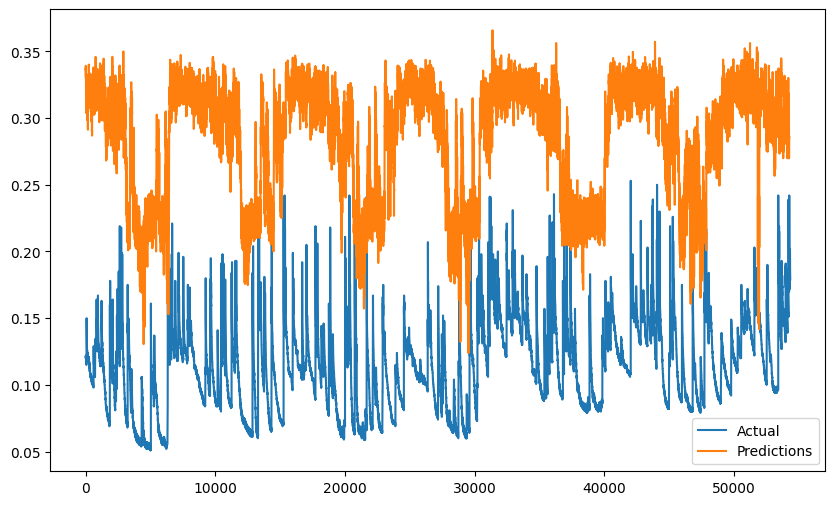

In [26]:
plot_single_pred(lstm_model, test_dataset, test_steps, y_test, batch_size=BATCH_SIZE)

In [27]:
y_pred = lstm_model.predict(test_dataset, batch_size=BATCH_SIZE, steps=test_steps)

424/424 [==============================] - 7s 17ms/step


In [28]:
y_true = y_test[0:len(y_pred)]

In [29]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_true, y_pred,squared = False)

0.17639445093253747

In [30]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_true, y_pred)

0.17202622813988203

In [31]:
from sklearn.metrics import mean_absolute_percentage_error
mean_absolute_percentage_error(y_true, y_pred)

1.6655740991773307

In [32]:
df_6 = dfs["Station6"]

In [33]:
train_set, val_set, test_set, target_idx = split_and_scale(df_6)

X_train, y_train = generate_windows(train_set, window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)
X_val, y_val = generate_windows(val_set, window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)
X_test, y_test = generate_windows(test_set, window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)

Index(['SWC_5', 'SWC_10', 'SWC_20', 'SWC_50', 'T_5', 'T_10', 'T_20', 'T_50',
       'Tair', 'RH', 'Srad', 'Ppt', 'Wx', 'Wy', 'Day sin', 'Day cos',
       'Year sin', 'Year cos', 'x_cord', 'y_cord', 'z_cord'],
      dtype='object')


In [34]:
train_dataset, train_steps = generate_batches(X_train, y_train, batch_size=BATCH_SIZE)
val_dataset, val_steps = generate_batches(X_val, y_val, batch_size=BATCH_SIZE)
test_dataset, test_steps = generate_batches(X_test, y_test, batch_size=BATCH_SIZE)

In [35]:

lstm_model.fit(train_dataset,
               epochs=MAX_EPOCHS,
               callbacks=[early_stopping, ckpt],
               validation_data=val_dataset,
               validation_steps = val_steps,
               shuffle=False,
               batch_size=BATCH_SIZE,
               steps_per_epoch = train_steps)

Epoch 1/50
295/295 [==============================] - 19s 65ms/step - loss: 0.0030 - mean_absolute_error: 0.0366 - mean_squared_error: 0.0030 - val_loss: 6.8557e-04 - val_mean_absolute_error: 0.0214 - val_mean_squared_error: 6.8557e-04
Epoch 2/50
295/295 [==============================] - 19s 66ms/step - loss: 7.9166e-04 - mean_absolute_error: 0.0224 - mean_squared_error: 7.9166e-04 - val_loss: 6.7022e-04 - val_mean_absolute_error: 0.0211 - val_mean_squared_error: 6.7022e-04
Epoch 3/50
295/295 [==============================] - 12s 41ms/step - loss: 7.6397e-04 - mean_absolute_error: 0.0219 - mean_squared_error: 7.6397e-04 - val_loss: 6.7208e-04 - val_mean_absolute_error: 0.0210 - val_mean_squared_error: 6.7208e-04
Epoch 4/50
295/295 [==============================] - 12s 41ms/step - loss: 7.5968e-04 - mean_absolute_error: 0.0218 - mean_squared_error: 7.5968e-04 - val_loss: 6.7294e-04 - val_mean_absolute_error: 0.0210 - val_mean_squared_error: 6.7294e-04
Epoch 5/50
295/295 [============

37/37 [==============================] - 1s 17ms/step


{'Predictions': array([0.14519247, 0.15633367, 0.14195451, ..., 0.13292693, 0.13233015,
        0.13282761], dtype=float32),
 'Actual': array([0.1  , 0.1  , 0.099, ..., 0.18 , 0.18 , 0.179])}

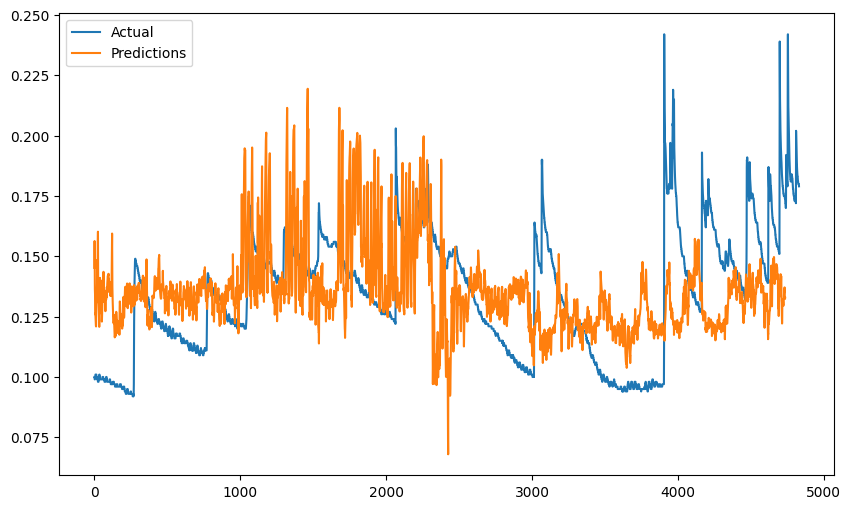

In [36]:
plot_single_pred(lstm_model, test_dataset, test_steps, y_test, batch_size=BATCH_SIZE)

In [37]:
y_pred = lstm_model.predict(test_dataset, batch_size=BATCH_SIZE, steps=test_steps)
y_true = y_test[0:len(y_pred)]

37/37 [==============================] - 1s 17ms/step


In [38]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_true, y_pred,squared = False)

0.027021851209418014

In [39]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_true, y_pred)

0.022007572566738

In [40]:
from sklearn.metrics import mean_absolute_percentage_error
mean_absolute_percentage_error(y_true, y_pred)

0.1687986161558903